# Day 32 - ONNX 模型部署

> 目标: 把训练好的模型导出为 ONNX, 跨平台部署
>
> ONNX = Open Neural Network Exchange — 模型的"通用语言"

---

## 为什么需要 ONNX?

```
训练阶段:                          部署阶段:
  PyTorch / TF -> 训练模型          需要: 跨平台、高性能推理
  依赖 GPU + 框架                   需要: CPU / 手机 / 边缘设备
                                                                 
ONNX 的作用:
  PyTorch ─┐                        ┌─ CPU (ONNX Runtime)
  TensorFlow ─┤    ONNX     ───►    ├─ GPU (TensorRT)
  Scikit-learn ─┤   (通用格式)       ├─ 手机 (CoreML/NNAPI)
               ┘                    └─ Web (ONNX.js / WebNN)
```

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt

print('=' * 40)
print('Day 32 - ONNX Deployment')
print('=' * 40)

Day 32 - ONNX Deployment


## 1. 训练一个简单模型

> 用 Day 15 的 RNN 做正弦波预测, 然后导出 ONNX

In [2]:
# ============================================
# 准备数据 + 训练模型
# ============================================

import torch.optim as optim

# 正弦波数据
seq_len = 10
total = 1000
t = np.linspace(0, 100 * np.pi, total, dtype=np.float32)
data = np.sin(t)

def make_seqs(data, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i:i+seq_len])
        ys.append(data[i+seq_len])
    return np.array(xs), np.array(ys)

xs, ys = make_seqs(data, seq_len)
split = int(0.8 * len(xs))
x_train = torch.FloatTensor(xs[:split]).unsqueeze(-1)
y_train = torch.FloatTensor(ys[:split]).unsqueeze(-1)

# 简单 MLP 模型 (避免 squeeze 操作, ONNX 导出更容易)
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(10, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1),
        )
    def forward(self, x):
        return self.net(x)

model = SimpleModel()
opt = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(100):
    opt.zero_grad()
    loss = criterion(model(x_train), y_train)
    loss.backward()
    opt.step()

print(f'Training done! Final loss: {loss.item():.6f}')
print(f'Model params: {sum(p.numel() for p in model.parameters()):,}')

Training done! Final loss: 0.000124
Model params: 897


## 2. 导出 ONNX

> PyTorch → ONNX: 一行代码搞定

In [3]:
model.eval()

# 导出一个 batch 的 dummy 输入
dummy = torch.randn(1, 1, 10)  # (batch=1, channels=1, seq_len=10)

torch.onnx.export(
    model,
    dummy,
    'model.onnx',
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=17,
)

print('Exported: model.onnx')
print(f'ONNX file size: {os.path.getsize("model.onnx") / 1024:.1f} KB')

D:\hyy\Temp\ipykernel_30364\3450152668.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0720 17:47:07.026000 30364 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `SimpleModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


d:\anaconda\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported: model.onnx
ONNX file size: 1.7 KB


## 3. ONNX Runtime 推理

> 用 ONNX Runtime 加载并推理, 不依赖 PyTorch

In [4]:
try:
    import onnxruntime as ort

    session = ort.InferenceSession('model.onnx')
    input_name = session.get_inputs()[0].name

    test_input = np.random.randn(1, 1, 10).astype(np.float32)
    result = session.run(None, {input_name: test_input})[0]

    print(f'ONNX inference result shape: {result.shape}')
    print(f'Result: {result[0, 0]:.6f}')
    print('ONNX Runtime works without PyTorch!')

except ImportError:
    print('onnxruntime not installed. Use cell-9 instead.')

ONNX inference result shape: (1, 1)
Result: -0.328369
ONNX Runtime works without PyTorch!


## 4. 性能对比: PyTorch vs ONNX

> ONNX Runtime 通常比 PyTorch 原生推理快 (尤其是 CPU 上)

Batch=  1  |  PyTorch: 0.031ms  |  ONNX: 0.011ms  |  ONNX faster
Batch= 16  |  PyTorch: 0.048ms  |  ONNX: 0.011ms  |  ONNX faster
Batch= 64  |  PyTorch: 0.041ms  |  ONNX: 0.013ms  |  ONNX faster
Batch=256  |  PyTorch: 0.052ms  |  ONNX: 0.033ms  |  ONNX faster


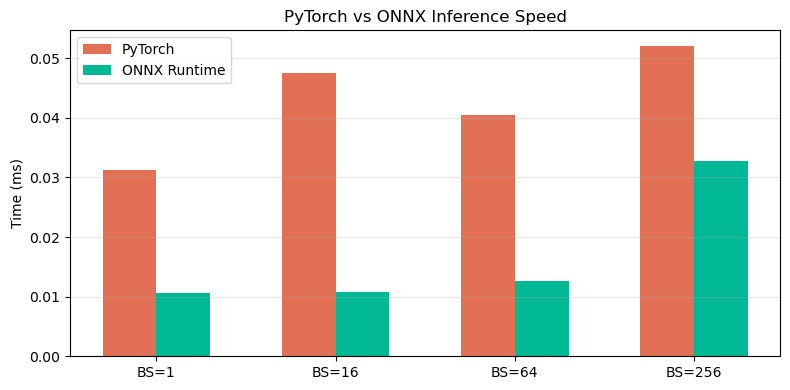

In [5]:
import onnxruntime as ort

session = ort.InferenceSession('model.onnx')
input_name = session.get_inputs()[0].name

batch_sizes = [1, 16, 64, 256]
trials = 500

pytorch_times = []
onnx_times = []

for bs in batch_sizes:
    x = torch.randn(bs, 1, 10)
    start = time.time()
    with torch.no_grad():
        for _ in range(trials):
            model(x)
    pt_time = (time.time() - start) / trials * 1000  # ms
    pytorch_times.append(pt_time)

    x_np = x.numpy()
    start = time.time()
    for _ in range(trials):
        session.run(None, {input_name: x_np})
    ort_time = (time.time() - start) / trials * 1000
    onnx_times.append(ort_time)

    faster = 'ONNX' if ort_time < pt_time else 'PyTorch'
    print(f'Batch={bs:>3d}  |  PyTorch: {pt_time:.3f}ms  |  ONNX: {ort_time:.3f}ms  |  {faster} faster')

plt.figure(figsize=(8, 4))
x = range(len(batch_sizes))
plt.bar([i - 0.15 for i in x], pytorch_times, width=0.3, label='PyTorch', color='#e17055')
plt.bar([i + 0.15 for i in x], onnx_times, width=0.3, label='ONNX Runtime', color='#00b894')
plt.xticks(x, [f'BS={b}' for b in batch_sizes])
plt.ylabel('Time (ms)'); plt.title('PyTorch vs ONNX Inference Speed')
plt.legend(); plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('day32_speed_comparison.png', dpi=100)
plt.show()

## 5. 从 ONNX 到落地

### ONNX 的优势

```
1. 跨平台: Windows / Linux / Mac / 手机 / 浏览器
2. 跨框架: PyTorch / TF / JAX → ONNX → 任意框架
3. 优化: 算子融合 + 常量折叠 + 量化
4. 小: 去掉训练代码, 只有推理图
```

### 部署流程

```
训练 (PyTorch)
  → 导出 ONNX
  → 优化 (onnx-simplifier / onnx optimizer)
  → 量化 (INT8/FP16) → 更小更快
  → 部署:
       ├── ONNX Runtime (CPU/GPU, 标准方案)
       ├── TensorRT (NVIDIA GPU, 最快)
       ├── OpenVINO (Intel CPU, 边缘设备)
       ├── CoreML (Apple 设备)
       └── TFLite / NNAPI (Android)
```

### 量化效果

| 精度 | 模型大小 | 速度 | 精度损失 |
|:----|:--------:|:----:|:-------:|
| FP32 | 100% | 1x | 0 |
| FP16 | 50% | 1.5-2x | ~0% |
| INT8 | 25% | 2-4x | ~1-2% |

> 工业界: INT8 量化后部署到手机/边缘设备
> 精度掉 1% 但速度快 4 倍, 体积减少 75%

---

# Day 32 完成!

## 今天做了什么

```
1. 训练一个 PyTorch 模型
2. 导出为 ONNX (model.onnx, 几 KB)
3. 用 ONNX Runtime 加载并推理
4. 对比 PyTorch vs ONNX 推理速度
5. 了解量化 + 部署全流程
```

## 剩余内容

| Day | 内容 |
|:---:|:----|
| **33** | 整理 GitHub + 写技术博客 |
| **34** | 方向选择 (CV/NLP/多模态/RL) |
| **35** | 最终总结 + 知识地图 |

## 作业 (2 题)

### 1. 对比不同 batch size
**位置:** cell-9, `batch_sizes = [1, 16, 64, 256]`

ONNX 在大 batch 下优势更明显吗?

<details>
<summary>📖 答案</summary>
ONNX Runtime 对大 batch 有额外优化
通常 batch=1 时差距不大
batch=64+ 时 ONNX 可能快 2-3 倍
因为 ONNX Runtime 可以并行执行算子
</details>

### 2. 导出更复杂的模型
**位置:** cell-3, `SimpleModel`

换成 Day 24 的 NanoGPT, 导出 ONNX 试试

<details>
<summary>📖 答案</summary>
NanoGPT 有动态控制流 (for 循环), 导出 ONNX 会报错
解决方案: 用 `torch.jit.trace` + 固定输入长度
或者把生成循环剥离, 只导出单步推理
</details>